# Covariance and Correlation

In [16]:
import pandas as pd
import numpy as np
pd.options.display.float_format='{:.4f}'.format
import matplotlib.pyplot as plt
plt.style.use('fast')
import seaborn as sns

In [9]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [10]:
close = pd.read_csv(r"C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\close.csv", index_col = "Date", parse_dates = ["Date"])
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,108.4067,383.6150,1.2628,1214.6000,38.8802,16804.7109
2014-10-02,107.9719,375.0720,1.2624,1214.2000,38.7616,16801.0508
2014-10-03,109.8762,359.5120,1.2671,1192.2000,39.0411,17009.6895
2014-10-04,NaN,328.8660,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.5100,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,242.4289,34323.0508
2021-05-27,250.7000,38436.9688,1.2193,1895.7000,240.3275,34464.6406
2021-05-28,247.0200,35697.6055,1.2193,1902.5000,240.6841,34529.4492


In [11]:
close['USDEUR=X']=1/close['EURUSD=X']
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,108.4067,383.6150,1.2628,1214.6000,38.8802,16804.7109,0.7919
2014-10-02,107.9719,375.0720,1.2624,1214.2000,38.7616,16801.0508,0.7921
2014-10-03,109.8762,359.5120,1.2671,1192.2000,39.0411,17009.6895,0.7892
2014-10-04,NaN,328.8660,NaN,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.5100,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,242.4289,34323.0508,0.8164
2021-05-27,250.7000,38436.9688,1.2193,1895.7000,240.3275,34464.6406,0.8202
2021-05-28,247.0200,35697.6055,1.2193,1902.5000,240.6841,34529.4492,0.8201


In [12]:
returns=close.apply(lambda x:np.log(x.dropna()/x.dropna().shift()))
returns

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-10-02,-0.0040,-0.0225,-0.0003,-0.0003,-0.0031,-0.0002,0.0003
2014-10-03,0.0175,-0.0424,0.0037,-0.0183,0.0072,0.0123,-0.0037
2014-10-04,NaN,-0.0891,NaN,NaN,NaN,NaN,NaN
2014-10-05,NaN,-0.0257,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2021-05-26,0.0026,0.0230,0.0028,0.0017,-0.0009,0.0003,-0.0028
2021-05-27,0.0379,-0.0221,-0.0046,-0.0029,-0.0087,0.0041,0.0046
2021-05-28,-0.0148,-0.0739,0.0000,0.0036,0.0015,0.0019,-0.0000


In [13]:
returns.cov() # covariance hard to interpret

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
BA,0.0007,0.0001,0.0000,0.0000,0.0002,0.0002,-0.0000
BTC-USD,0.0001,0.0016,-0.0000,0.0000,0.0001,0.0001,0.0000
EURUSD=X,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000
GC=F,0.0000,0.0000,0.0000,0.0001,-0.0000,-0.0000,-0.0000
MSFT,0.0002,0.0001,-0.0000,-0.0000,0.0003,0.0002,0.0000
^DJI,0.0002,0.0001,0.0000,-0.0000,0.0002,0.0001,-0.0000
USDEUR=X,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000


In [14]:
returns.corr() # correlation coefficient easy to interpret

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
BA,1.0000,0.1325,0.0340,0.0044,0.4225,0.7251,-0.0340
BTC-USD,0.1325,1.0000,-0.0163,0.0986,0.1439,0.1604,0.0163
EURUSD=X,0.0340,-0.0163,1.0000,0.0565,-0.0203,0.0295,-1.0000
GC=F,0.0044,0.0986,0.0565,1.0000,-0.0022,-0.0121,-0.0565
MSFT,0.4225,0.1439,-0.0203,-0.0022,1.0000,0.7427,0.0203
^DJI,0.7251,0.1604,0.0295,-0.0121,0.7427,1.0000,-0.0295
USDEUR=X,-0.0340,0.0163,-1.0000,-0.0565,0.0203,-0.0295,1.0000


**Three cases:
- no correlation: coefficient ==0
- positive correlation: 0 until 1
- negative correlation: -1 until 0**

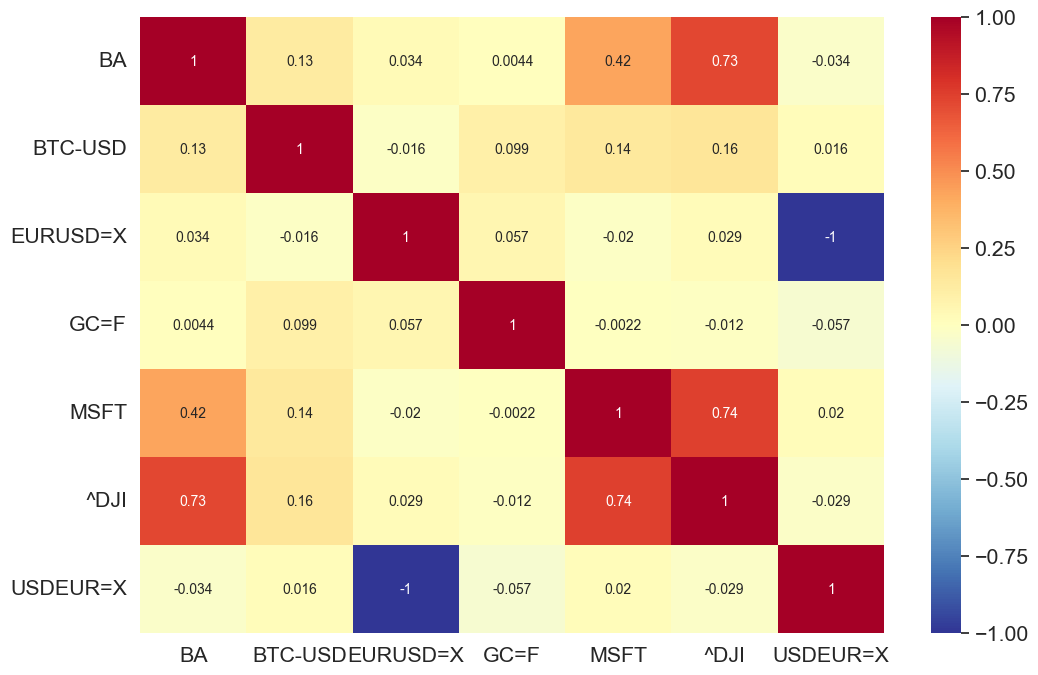

In [17]:
plt.figure(figsize=(12,8))
sns.set(font_scale=1.4)
sns.heatmap(returns.corr(),cmap='RdYlBu_r',annot=True,annot_kws={'size':10},vmin=-1,vmax=1)
plt.show()